<a href="https://colab.research.google.com/github/PTRWNG-wzl/Computer_Vision_2026/blob/main/08_RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Reinforcement Learning: An Introduction

In this tutorial, we will enter the world of Deep Reinforcement Learning (DRL). In particular, we will first familiarize ourselves with some basic concepts of Reinforcement Learning (RL), then we will implement a classical tabular Q-learning method for the classic [Frozen Lake](https://gym.openai.com/envs/FrozenLake-v0/) puzzle and finally, implement a Deep Q-learning approach for the [CartPole](https://gym.openai.com/envs/CartPole-v1/) problem.


>



![alt text](https://media2.giphy.com/media/46ib09ZL1SdWuREnj3/giphy.gif?cid=3640f6095c6e92762f3446634d90bc65) ![alt text](https://media0.giphy.com/media/d9QiBcfzg64Io/200w.webp?cid=3640f6095c6e93e92f30655873731752)![alt text](https://i.gifer.com/GpAY.gif)

The gifs above, show the results obtained by [Deepmind](https://arxiv.org/pdf/1312.5602v1.pdf) in one of their latest papers. They successfully trained an RL agent using deep Q-learning to play classical Atari arcade games. Let's see now how they did it.








# Q-Learning

This family of RL methods try to learn an approximator of the action-value functions $Q(s,a)$  based on the [Bellman equation](https://en.wikipedia.org/wiki/Bellman_equation), such that the update using a classical [gradient descent ](https://en.wikipedia.org/wiki/Gradient_descent) formulation is given by:
$$Q\left(s,a\right)=Q\left(s,a\right)+ \alpha \left(r+\gamma \max _{a} Q\left(s_{t+1},a\right)-Q\left(s,a\right)\right).$$
Where $\alpha$ is the step size.
 Q-Learning updates the estimated reward at each time step and  uses the old estimate $ \max _{a}Q\left(s_{t+1},a\right)$ to update the new ones. In a more algorithmic way, the Q-Learning process is the following:


1.   Initialize Q-values at random $Q\left(s,a\right)$.
2. Forever or until learning is stopped do:
> 1.  Observe state $s$.
> 2.   Take action $a$ according to your policy, e.g., $\epsilon$-greedy.
> 3.   Observe reward $r$ and new state $s_{t+1}$.
> 4. Based on your actual estimates, compute $\max _{a}Q\left(s_{t+1},a\right)$.
> 5. Update your current estimate for  $Q\left(s,a\right)$:
$$Q\left(s,a\right)=Q\left(s,a\right)+ \alpha \left(r+\gamma \max _{a} Q\left(s_{t+1},a\right)-Q\left(s,a\right)\right).$$

Okay, now that we are familiar with Q-Learning lets jump to a real implementation of it.







## Tabular Q-Learning with Frozen Lake
In this section we will teach an agent how to play  the [Frozen lake](https://gym.openai.com/envs/FrozenLake-v0/) game using a classical tabular Q-learning. Brace yourselves, winter is coming!

![alt text](https://raw.githubusercontent.com/simoninithomas/Deep_reinforcement_learning_Course/1ee37cfc3130057f828f19b3cee6066d41c1eeb4/Q%20learning/FrozenLake/frozenlake.png)

Winter has arrived and you and your friends were tossing around a frisbee at the park when you made a wild throw that left the frisbee out in the middle of the lake. The water is mostly frozen, but there are a few holes where the ice has melted. If you step into one of those holes, you'll fall into the freezing water. At this time, there's an international frisbee shortage, so you must navigate across the lake and retrieve the disc. However, the ice is slippery, so you won't always move in the direction you intend.
The goal of this game is to go from the starting state (S) to the goal state (G) by walking only on frozen tiles (F) and avoid holes (H). However, the ice is slippery (!!), so you won't always move in the direction you intend (stochastic environment), i.e., there is a probability $p$ that you move in the direction selected and a probability $(1-p)$ that given the slippery ice, you move to a random position near position. Specifically, let's say you select the action UP, you have a probability of 1/3 of actually going UP, 1/3 of going RIGHT and 1/3 of going LEFT. Similarly, if you select LEFT, you have a probability of 1/3 of actually going LEFT, 1/3 of going UP and 1/3 of going DOWN.

The lake is represented by a 4x4 grid and the location where the frisbee has landed (G) as well as the holes (H) is always the same for every new game. The game is restarted every time you have successfully recovered the frisbee or you have fallen into the cold waters. A reward of +1 is given every time you recover the frisbee and 0 other way.


**Step 0: Import the needed libraries:**

We will be using 3 libraries:

* Numpy for our Qtable.
* OpenAI Gym for our FrozenLake Environment
* Random to generate random numbers



In [1]:
!pip install gymnasium --upgrade

import base64
import collections
import glob
import io
import os
import random
import time
import torch

from IPython import display as ipythondisplay
from IPython.display import HTML
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

def set_seed(seed: int) -> None:
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Environment creation:**

OpenAi is  a library composed of many environments that we can use to train our agents, in our case we choose to use the Frozen Lake.

In [2]:
env = gym.make("FrozenLake-v1", render_mode='rgb_array')

**Q-table**

 Now, we'll create our Q-table. The goal of the Q-table is to store the estimates $Q\left(s,a\right)$ and retrieve them when necessary. In this game the states are represented by each of the 16 grid positions being 0 the starting position and 16 the goal position and the actions are 4: left, right, up and down. Our Q-table will have then $16 \times 4$ positions, where the value of the first column of the first row represents the expected return of being in position 0 and taking left.

The number of rows (states) and columns (actions) the table will have can also be obtained using the values action_size and the state_size from the OpenAI Gym library: *env.action_space.n* and* env.observation_space.n*.

We initialize the table to 0.

In [3]:
action_size = env.action_space.n
state_size = env.observation_space.n
qtable = np.zeros((state_size, action_size))
print(qtable)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


**Hyperparameters**

Following, we specify the hyperparameters:


In [4]:
total_episodes = 25000        # Total episodes
learning_rate = 0.8           # Learning rate (alpha in the previous formulation)
max_steps = 100               # Max steps per episode
gamma = 0.95                  # Discounting rate

At first, we don't know how to interact with the environment (Q-table values set to 0), so we start exploring it by taking a random action with probability $\epsilon=1$, capturing the rewards obtained and updating the Q-values of the table accordingly. As time passes by, we start knowing more and more the environment, so we reduce (decay_rate) the probability of taking a random action and we start exploiting our knowledge, we choose the action that leads us to the highest reward, i.e., the one with the highest Q-value.

In [5]:
# Exploration parameters
max_epsilon = 1.0             # Exploration probability at start
min_epsilon = 0.01            # Minimum exploration probability
epsilon = max_epsilon         # Exploration rate
decay_rate = 0.001            # Exponential decay rate for exploration prob

**Q-Learning**

Now we implement the Q-Learning algorithm:
> 1.  Observe state $s$.
> 2.   Choose a random value $v$ between 0 and 1.
> 3. If $v<\epsilon$, we choose a random action, otherwise we select the action with maximum $Q(s,a)$.
> 3.   Observe reward $r$ and new state $s_{t+1}$.
> 4. Based on your previous estimates, compute $\max _{a}Q\left(s_{t+1},a\right)$.
> 5. Update your current estimates for  $Q\left(s,a\right)$:
$$Q\left(s,a\right)=Q\left(s,a\right)+ \alpha \left(r+\gamma \max _{a} Q\left(s_{t+1},a\right)-Q\left(s,a\right)\right).$$


In [6]:
set_seed(0)

# List of rewards
rewards = []

for episode in range(total_episodes):
    # Reset the environment
    state, _ = env.reset()
    step = 0
    done = False
    total_rewards = 0

    for step in range(max_steps):
        # 3. Choose an action a in the current world state (s)
        ## First we randomize a number
        exp_exp_tradeoff = random.uniform(0, 1)

        ## If this number > greater than epsilon --> exploitation (taking the biggest Q value for this state)
        if exp_exp_tradeoff > epsilon:
            action = np.argmax(qtable[state,:])

        # Else doing a random choice --> exploration
        else:
            action = env.action_space.sample()

        # Take the action (a) and observe the outcome state(s') and reward (r)
        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
        # qtable[new_state,:] : all the actions we can take from new state
        qtable[state, action] = qtable[state, action] + learning_rate * (reward + gamma * np.max(qtable[new_state, :]) - qtable[state, action])

        total_rewards += reward

        # Our new state is state
        state = new_state

        # If done (if we're dead) : finish episode
        if done == True:
            break

    # Reduce epsilon (because we need less and less exploration)
    epsilon = min_epsilon + (max_epsilon - min_epsilon)*np.exp(-decay_rate*episode)
    rewards.append(total_rewards)

print ("Score over time: " +  str(sum(rewards)/total_episodes))
print(qtable)

Score over time: 0.43676
[[2.76745502e-01 3.14608254e-02 2.40838027e-02 3.78218461e-02]
 [3.00333823e-03 1.47603197e-04 5.08007245e-03 1.24104930e-01]
 [7.61650282e-03 1.81745758e-03 6.47465840e-03 1.74277936e-01]
 [1.87752718e-03 4.80675660e-03 5.90241756e-03 4.68461947e-02]
 [4.12879591e-01 1.06719326e-03 7.63280316e-02 3.09107629e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.87364414e-04 2.70112771e-10 1.83940637e-02 3.70715001e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.96013900e-02 1.07218769e-02 1.36198756e-02 5.63654865e-01]
 [1.19767683e-03 6.30120695e-01 2.24491169e-02 7.76995608e-03]
 [2.00454736e-01 4.03439960e-04 2.40936773e-04 5.47972531e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [8.16656862e-02 4.95700186e-03 6.89449068e-01 1.07519141e-02]
 [1.18100426e-01 9.49260216e-01 8.97683409e-02 9.70323597e-02]
 [0.00000000e+00 0.00000000e+0

**Use our Q-table to play FrozenLake!**

After 25000 episodes, our Q-table can be used as a "cheatsheet" to play FrozenLake"!
  
By running this cell, you can see our agent playing FrozenLake:

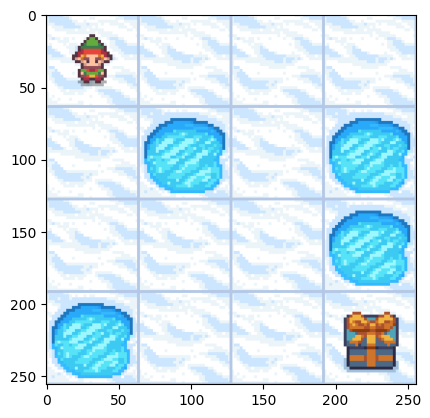

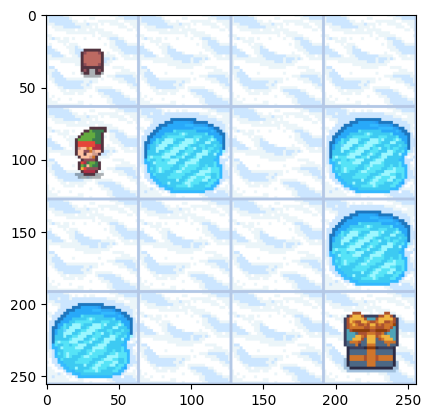

Number of steps: 0


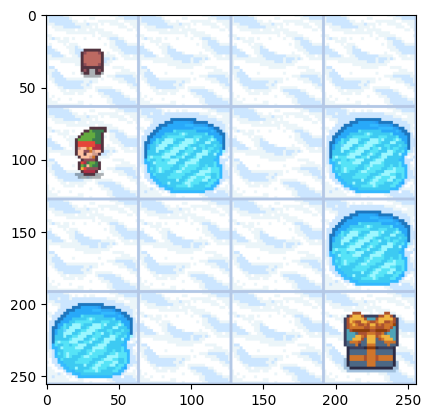

Number of steps: 1


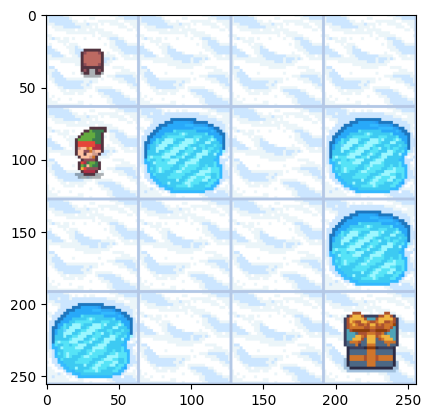

Number of steps: 2


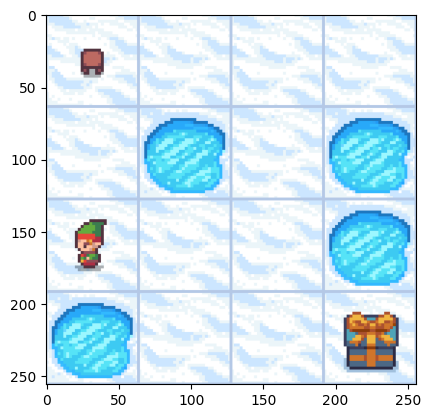

Number of steps: 3


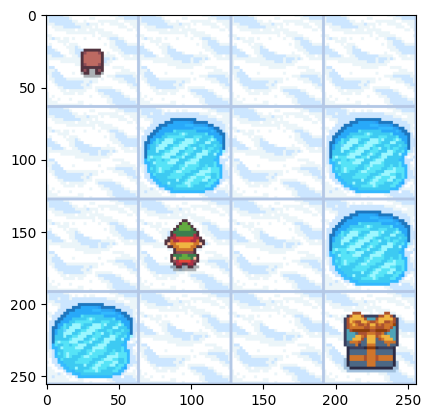

Number of steps: 4


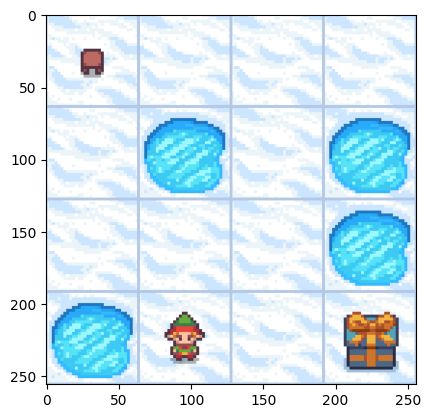

Number of steps: 5


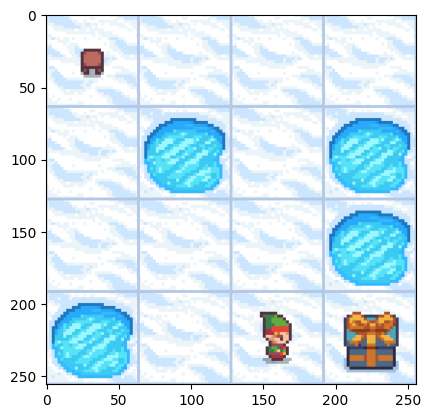

Number of steps: 6


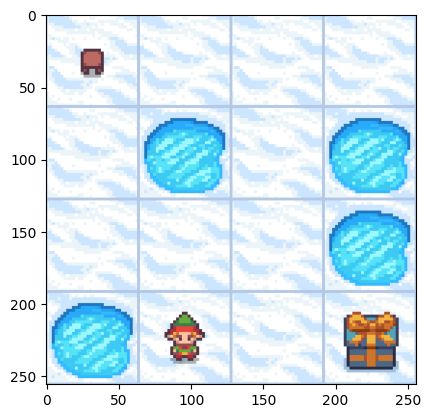

Number of steps: 7


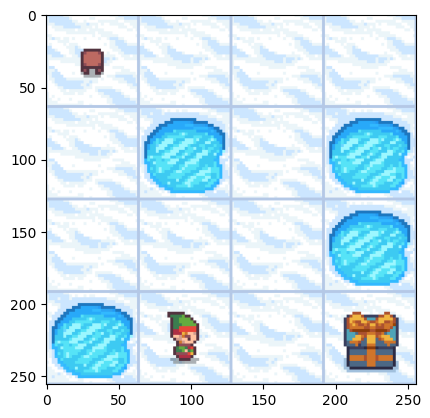

Number of steps: 8


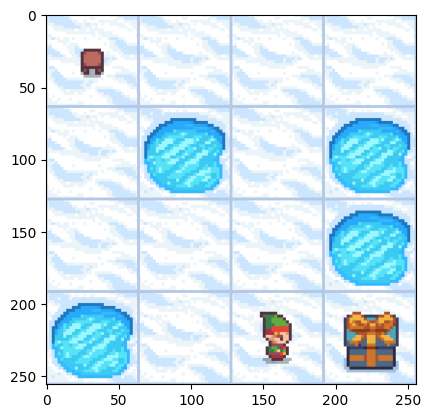

Number of steps: 9


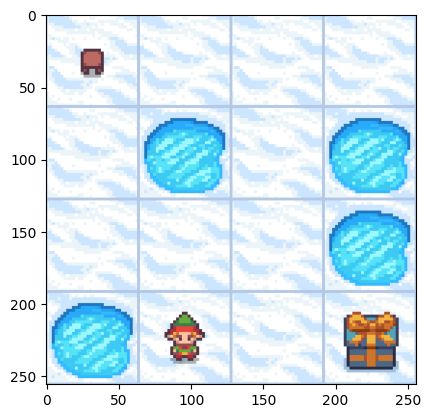

Number of steps: 10


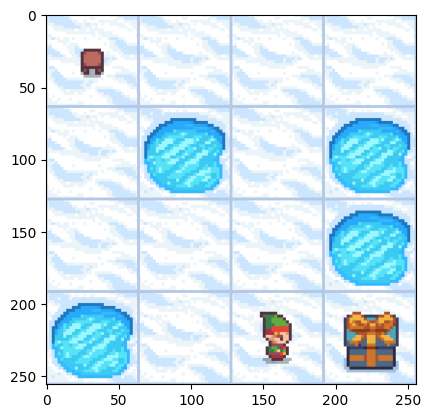

Number of steps: 11


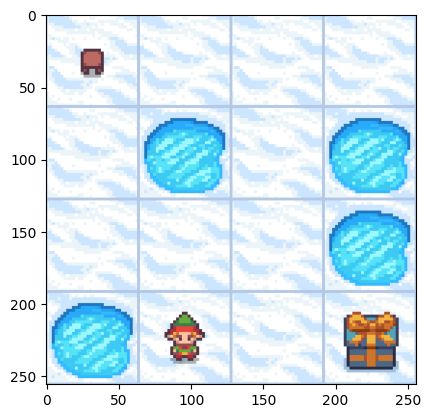

Number of steps: 12


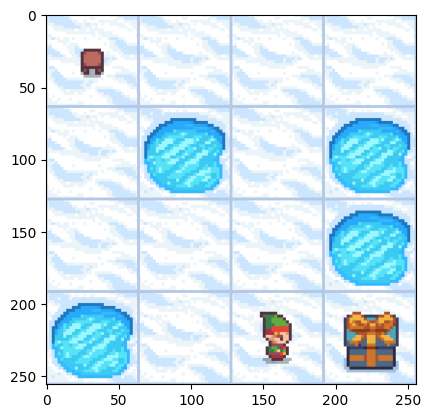

Number of steps: 13


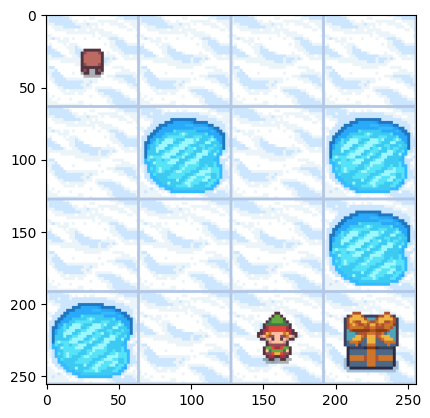

Number of steps: 14


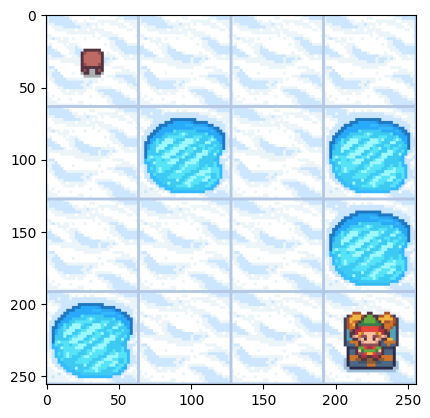

Number of steps: 15


In [7]:
env = gym.make("FrozenLake-v1", render_mode='rgb_array')
state, _ = env.reset()
step = 0

plt.imshow(env.render())
plt.show()

for step in range(max_steps):

    # Take the action (index) that have the maximum expected future reward given that state
    action = np.argmax(qtable[state,:])

    new_state, reward, terminated, truncated, info = env.step(action)
    plt.imshow(env.render())
    plt.show()

    # We print the current step.
    print(f"Number of steps: {step}")
    if terminated or truncated:
      break
    state = new_state

env.close()

Let’s see how many times our agent finds the frisbee 🎉

To this end we will print the last step of the game.

In [8]:
set_seed(0)

games=5
for game in range(games):
    env = gym.make("FrozenLake-v1")
    state, _ = env.reset()
    step = 0
    for step in range(max_steps):

        # Take the action (index) that have the maximum expected future reward given that state
        action = np.argmax(qtable[state,:])
        new_state, reward, terminated, truncated, info = env.step(action)

        if terminated or truncated:
        # Here, we decide to only print the last state (to see if our agent is on the goal or fall into a hole)
        # We print the number of step it took.
            print(f"Succeed: {reward == 1}, Number of steps: {step}")
            break
        state = new_state
    env.close()

Succeed: True, Number of steps: 24
Succeed: True, Number of steps: 82
Succeed: True, Number of steps: 19
Succeed: False, Number of steps: 24
Succeed: True, Number of steps: 19


In [9]:
set_seed(0)

games = 1000
total_rewards = 0

for game in range(games):
    env = gym.make("FrozenLake-v1")
    state, _ = env.reset()
    step = 0
    for step in range(max_steps):
        # Take the action (index) that have the maximum expected future reward given that state
        action = np.argmax(qtable[state,:])
        new_state, reward, terminated, truncated, info = env.step(action)
        if terminated or truncated:
            total_rewards += reward
            break
        state = new_state
    env.close()
success = total_rewards / games
print("Ratio of sucessfully finished episodes is {:f}".format(success))

Ratio of sucessfully finished episodes is 0.730000


## CartPole

That wasn't so hard! How about trying to balance a pole so it does not fall? In this section we will address the [CartPole](https://gym.openai.com/envs/CartPole-v1/) problem, let's get to it!

![texto alternativo](https://keon.github.io/images/deep-q-learning/animation.gif)

As before we will use Q-learning to train our agent, so let's start by constructing our Q-table. We first need to find out the number of columns and rows of it. By checking the environment specifications of [OpenAi](https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py), we see that the actions are left and right, so we need two columns for the actions. On the other hand, the state information is given by:

        Num	Observation                 Min         Max
        0	Cart Position             -4.8            4.8
        1	Cart Velocity             -Inf            Inf
        2	Pole Angle                 -24 deg        24 deg
        3	Pole Velocity At Tip      -Inf            Inf
      
The cart position goes from -4.8 to 4.8 with a resolution of 0.01, which means $\frac{4.8 \times 2}{0.01}=960$ possible carts positions, while the cart velocity goes from $-\infty$ to $\infty$!. How we are going to construct a table with $\infty$ rows?

Do not panic! That is when deep learning steps up and takes over the stage. As you have already seen the use of Deep Neural Networks as general function approximators have been proven to work very well in a wide range of areas, reinforcement learning is not an exception. In this case we will use the NNs as function approximation between the mapping of states to actions, so for every input state, we want the NNs to output an approximation of the $Q\left(s,a\right)$.

![alt text](https://proxy.duckduckgo.com/iu/?u=https%3A%2F%2Fcdn-images-1.medium.com%2Fmax%2F1318%2F1*Gh5PS4R_A5drl5ebd_gNrg%402x.png&f=1)

In this particular scenario, the input layer will have the same number of inputs as environment parameters, 4, and the output layer will have the same number of outputs as actions, in this case 2.

**Reward:** A reward of +1 is provided for every timestep that the pole remains upright. The episode ends when the pole is more than 15 degrees from vertical.



**Step 0: Import the needed libraries**

We start by importing the needed libraries:
We will be using 3 libraries:
* PyTorch: for our DNNs.
* OpenAI Gym: for our CartPole Environment
* Random: to generate random numbers.
* Collections: Collection will be use to create a memory buffer to store the tuples $\left(S_t, A_t, R_t,S_{t+1}\right)$ of transactions.

The idea behind the use of a memory buffer is that most optimization algorithms, including gradient descent, assume that the samples used in an update step are independent and identically distributed. Clearly in the defined environment that is not the case, however, by sampling uniformly the memory buffer with a high number of samples the correlation between contiguous samples is broken and less likely to be correlated samples are used to update the network's weights, leading to a stable optimization of the action-parameter selection.


**The Agent**

Let's start by coding a general DQ-Learning agent. The state and action size are passed as parameters and we configure a replay buffer to have capacity to store 2000 experienced transitions.

In [10]:
class DQNAgent:
    def __init__(self, state_size, action_size, device=None):
        self.state_size   = state_size
        self.action_size  = action_size
        self.memory       = collections.deque(maxlen=2000)
        self.gamma        = 0.95       # discount rate
        self.epsilon      = 1.0        # exploration rate
        self.epsilon_min  = 0.01
        self.epsilon_decay= 0.995
        self.learning_rate= 0.001

        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model  = self._build_model().to(self.device)
        self.opt    = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.loss_fn= nn.MSELoss()

    def _build_model(self):
        # 2×24 MLP
        model = nn.Sequential(
            nn.Linear(self.state_size, 24),
            nn.ReLU(),
            nn.Linear(24, 24),
            nn.ReLU(),
            nn.Linear(24, self.action_size)  # Q(s, ·) logits (no activation)
        )
        return model

    # ---- replay buffer ----
    def remember(self, state, action, reward, next_state, done):
        # store numpy arrays (state/next_state should be shape (1, state_size))
        self.memory.append((state, action, reward, next_state, done))

    # ---- policies ----
    def act(self, state):
        # state: numpy array shape (1, state_size)
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        self.model.eval()
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.float32, device=self.device)
            q = self.model(s)  # (1, A)
            return int(torch.argmax(q, dim=1).item())

    def exploit(self, state):
        self.model.eval()
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.float32, device=self.device)
            q = self.model(s)
            return int(torch.argmax(q, dim=1).item())

    # ---- learning step ----
    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return
        minibatch = random.sample(self.memory, batch_size)

        # stack to tensors
        state_b      = torch.as_tensor(np.vstack([m[0] for m in minibatch]),
                                       dtype=torch.float32, device=self.device)   # (B, S)
        action_b     = torch.as_tensor([m[1] for m in minibatch],
                                       dtype=torch.long, device=self.device)      # (B,)
        reward_b     = torch.as_tensor([m[2] for m in minibatch],
                                       dtype=torch.float32, device=self.device)   # (B,)
        next_state_b = torch.as_tensor(np.vstack([m[3] for m in minibatch]),
                                       dtype=torch.float32, device=self.device)   # (B, S)
        done_b       = torch.as_tensor([m[4] for m in minibatch],
                                       dtype=torch.float32, device=self.device)   # (B,)

        # target = r + gamma * max_a' Q(next_state, a'); if done -> r
        self.model.eval()
        with torch.no_grad():
            next_q_max = self.model(next_state_b).max(dim=1).values               # (B,)
            target_scalar = reward_b + self.gamma * next_q_max * (1.0 - done_b)   # (B,)

            # target_f starts as current Q(s,·), then we overwrite the taken action
            target_full = self.model(state_b).clone()                              # (B, A)
            target_full[torch.arange(batch_size), action_b] = target_scalar

        # train to fit full target vector
        self.model.train()
        pred_q = self.model(state_b)                                               # (B, A)
        loss = self.loss_fn(pred_q, target_full)

        self.opt.zero_grad()
        loss.backward()
        self.opt.step()

        # epsilon decay
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    # ---- save/load ----
    def save(self, path):
        torch.save(self.model.state_dict(), path)

    def load(self, path):
        state = torch.load(path, map_location=self.device)
        self.model.load_state_dict(state)
        self.model.to(self.device)
        self.model.eval()

**Main**

Following we implement the training of the agent. (Warning: it takes a while...)

In [11]:
EPISODES = 200
env = gym.make('CartPole-v1')
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
agent = DQNAgent(state_size, action_size)
batch_size = 32

for e in range(EPISODES):
    state, _ = env.reset()
    state = np.reshape(state, [1, state_size])
    for time in range(200):
        action = agent.act(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_state = np.reshape(next_state, [1, state_size])
        agent.remember(state, action, reward, next_state, done)
        state = next_state
        if done:
            break

        if len(agent.memory) > batch_size:
            agent.replay(batch_size)
    print("episode: {}/{}, score: {}, e: {:.2}"
                  .format(e, EPISODES, time, agent.epsilon))

episode: 0/200, score: 12, e: 1.0
episode: 1/200, score: 17, e: 1.0
episode: 2/200, score: 18, e: 0.92
episode: 3/200, score: 26, e: 0.81
episode: 4/200, score: 12, e: 0.76
episode: 5/200, score: 13, e: 0.71
episode: 6/200, score: 11, e: 0.67
episode: 7/200, score: 9, e: 0.64
episode: 8/200, score: 17, e: 0.59
episode: 9/200, score: 9, e: 0.56
episode: 10/200, score: 11, e: 0.53
episode: 11/200, score: 8, e: 0.51
episode: 12/200, score: 10, e: 0.49
episode: 13/200, score: 9, e: 0.47
episode: 14/200, score: 8, e: 0.45
episode: 15/200, score: 10, e: 0.43
episode: 16/200, score: 11, e: 0.4
episode: 17/200, score: 11, e: 0.38
episode: 18/200, score: 10, e: 0.36
episode: 19/200, score: 9, e: 0.35
episode: 20/200, score: 10, e: 0.33
episode: 21/200, score: 9, e: 0.32
episode: 22/200, score: 11, e: 0.3
episode: 23/200, score: 11, e: 0.28
episode: 24/200, score: 12, e: 0.27
episode: 25/200, score: 11, e: 0.25
episode: 26/200, score: 10, e: 0.24
episode: 27/200, score: 11, e: 0.23
episode: 28/2

Let's now visualize how the agent is performing:

In [12]:
"""
Utility functions to enable video recording of gym environment and displaying it
To enable video, just do "env = wrap_env(env)""
"""

def show_video():
  mp4list = glob.glob('video/*.mp4')
  if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    ipythondisplay.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
  else:
    print("Could not find video")


def wrap_env(env):
  env = gym.wrappers.RecordVideo(env, './video')
  return env

In [13]:
env = wrap_env(gym.make('CartPole-v1', render_mode='rgb_array'))
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
state, _ = env.reset()
state = np.reshape(state, [1, state_size])
for time in range(200):
    screen = env.render()
    action = agent.exploit(state)
    state, reward, terminated, truncated, _ = env.step(action)
    if terminated or truncated:
      break
    state = np.reshape(state, [1, state_size])

env.close()
show_video()

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


You can have a look of the tutorials and code prepared by [OpenAI](https://spinningup.openai.com/en/latest/user/introduction.html) for further details on RL.

# Coursework

## Task 1: On-policy vs. Off-policy
Use the code given below to run the training loop, where the agent is trained for 200 episodes. The agent we give follows a Q-learning approach, which is an off-policy approach. You will now change the approach to SARSA, which is an on-policy approach. Also, for both Q-learning and SARSA test two different policies: $\epsilon$-greedy and Softmax. $\epsilon$-greedy is already defined in the tutorial and implemented in the given agent. Softmax policy refers to sampling the next action following the probability distribution given by $Softmax(Q(s, a))$. We provide you the NumPy softmax function to normalize the Q-Values into a probability function to use before sampling. Similarly to RNN, in the softmax function, there is a temperature value involved, we set a default value that works, but you can tweak it if you find another value with better performance. Report the new value if you decide to do so.

You will need to modify `act` and `replay` from the `DQNAgent` to implement the different approaches we ask for. Results may differ from run to run due to different initialization states.

**Report**
* Plot the average reward for the last 50 episodes vs. number of training episodes (train for 200 episodes) for the four agents trained: Q-learning and SARSA with both $\epsilon$-greedy policy and Softmax policy.

* Attach in the Appendix the modifications done to `DQNAgent` to implement the different agents. Do not include your code, a simple explanation with the key modifications is enough.

* In addition to the average reward plot, include **at least one secondary plot** that illustrates the behavioral differences between the four agents. For example, you might consider:

  ---

  **$\epsilon$-greedy vs. Softmax**

  * **Fraction of greedy actions**  
  Proportion of times in an episode the agent chooses the action with the highest estimated Q-value.  
  Shows how quickly exploration gives way to exploitation, and is useful when comparing ϵ-greedy and Softmax.  

  * **Average policy entropy**  
  A measure of how “spread out” the action probabilities are per-step in an episode (compute an episode average).  
  High entropy means the agent is exploring more uniformly; low entropy means it is being more deterministic.  

  ---

  **Q-Learning vs. SARSA**

  * **Variance of returns**  
  Plot a rolling variance across episodes of total episode reward (e.g., window = 20).  
  Highlights stability differences between Q-Learning and SARSA.  

  * **Average Temporal-difference (TD) error magnitude**  
  Measures how different the agent’s current Q-value estimate is from the updated target it just computed.  
  Captures how big the agent’s “surprise” is at each step.  

    - For Q-learning (off-policy):  
      $
      \delta = \left| r + \gamma \max_{a} Q(s', a) - Q(s, a) \right|
      $

    - For SARSA (on-policy):  
      $
      \delta = \left| r + \gamma Q(s', a') - Q(s, a) \right|, \quad $where  $a'$ is the next action chosen by the policy.


    Large TD errors mean the agent is still making big adjustments (its predictions are far off).  
    Smaller TD errors suggest the estimates are stabilizing.  

  ---

  These are suggestions — you are welcome to choose other metrics if you find them insightful, as long as you clearly explain how your plot highlights differences between the agents.
  
  To make trends easier to see, consider smoothing your plots with a **moving average** across episodes (e.g. a 20-episode window).



In [14]:
def softmax(x, temperature=0.025):
    """Compute softmax values for each sets of scores in x."""
    x = (x - np.expand_dims(np.max(x, 1), 1))
    x = x / max(temperature, 1e-6)
    e_x = np.exp(x)
    return e_x / (np.expand_dims(e_x.sum(1), -1) + 1e-5)


class DQNAgent:
    def __init__(
        self,
        state_size,
        action_size,
        algorithm="q_learning",
        policy="epsilon_greedy",
        temperature=0.025,
        device=None,
    ):
        self.state_size = state_size
        self.action_size = action_size
        self.algorithm = algorithm
        self.policy = policy
        self.temperature = temperature
        self.memory = collections.deque(maxlen=20000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.last_td_error = None

        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = self._build_model().to(self.device)
        self.opt = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.loss_fn = nn.MSELoss()

    def _build_model(self):
        return nn.Sequential(
            nn.Linear(self.state_size, 24),
            nn.ReLU(),
            nn.Linear(24, 48),
            nn.ReLU(),
            nn.Linear(48, self.action_size),
        )

    def remember(self, state, action, reward, next_state, next_action, done):
        self.memory.append((state, action, reward, next_state, next_action, done))

    def _get_q_values(self, state):
        self.model.eval()
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.float32, device=self.device)
            q = self.model(s)
        return q

    def act(self, state):
        q = self._get_q_values(state)
        q_np = q.detach().cpu().numpy()
        greedy_action = int(np.argmax(q_np, axis=1)[0])

        if self.policy == "softmax":
            probs = softmax(q_np, temperature=self.temperature)[0]
            action = int(np.random.choice(self.action_size, p=probs))
        else:
            if np.random.rand() <= self.epsilon:
                action = random.randrange(self.action_size)
            else:
                action = greedy_action
            probs = np.ones(self.action_size) * (self.epsilon / self.action_size)
            probs[greedy_action] += 1.0 - self.epsilon

        entropy = float(-(probs * np.log(probs + 1e-8)).sum())
        return action, {"is_greedy": int(action == greedy_action), "entropy": entropy}

    def exploit(self, state):
        q = self._get_q_values(state)
        return int(torch.argmax(q, dim=1).item())

    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return None

        minibatch = random.sample(self.memory, batch_size)
        state_b = torch.as_tensor(np.vstack([m[0] for m in minibatch]), dtype=torch.float32, device=self.device)
        action_b = torch.as_tensor([m[1] for m in minibatch], dtype=torch.long, device=self.device)
        reward_b = torch.as_tensor([m[2] for m in minibatch], dtype=torch.float32, device=self.device)
        next_state_b = torch.as_tensor(np.vstack([m[3] for m in minibatch]), dtype=torch.float32, device=self.device)
        next_action_b = torch.as_tensor([
            0 if m[4] is None else m[4] for m in minibatch
        ], dtype=torch.long, device=self.device)
        done_b = torch.as_tensor([m[5] for m in minibatch], dtype=torch.float32, device=self.device)

        self.model.eval()
        with torch.no_grad():
            next_q = self.model(next_state_b)
            if self.algorithm == "sarsa":
                next_q_selected = next_q.gather(1, next_action_b.unsqueeze(1)).squeeze(1)
            else:
                next_q_selected = next_q.max(dim=1).values
            target = reward_b + self.gamma * next_q_selected * (1.0 - done_b)

        self.model.train()
        current_q = self.model(state_b).gather(1, action_b.unsqueeze(1)).squeeze(1)
        loss = self.loss_fn(current_q, target)

        self.opt.zero_grad()
        loss.backward()
        self.opt.step()

        td_error = torch.abs(target.detach() - current_q.detach()).mean().item()
        self.last_td_error = td_error

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

        return td_error

    def save(self, path):
        torch.save(self.model.state_dict(), path)

    def load(self, path):
        state = torch.load(path, map_location=self.device)
        self.model.load_state_dict(state)
        self.model.to(self.device)
        self.model.eval()

[q_learning | epsilon_greedy] episode: 1/200, score: 20.0, epsilon: 1.000, last 50 avg reward: 20.00
[q_learning | epsilon_greedy] episode: 2/200, score: 11.0, epsilon: 1.000, last 50 avg reward: 15.50
[q_learning | epsilon_greedy] episode: 3/200, score: 39.0, epsilon: 0.827, last 50 avg reward: 23.33
[q_learning | epsilon_greedy] episode: 4/200, score: 24.0, epsilon: 0.733, last 50 avg reward: 23.50
[q_learning | epsilon_greedy] episode: 5/200, score: 19.0, epsilon: 0.666, last 50 avg reward: 22.60
[q_learning | epsilon_greedy] episode: 6/200, score: 20.0, epsilon: 0.603, last 50 avg reward: 22.17
[q_learning | epsilon_greedy] episode: 7/200, score: 15.0, epsilon: 0.559, last 50 avg reward: 21.14
[q_learning | epsilon_greedy] episode: 8/200, score: 19.0, epsilon: 0.508, last 50 avg reward: 20.88
[q_learning | epsilon_greedy] episode: 9/200, score: 9.0, epsilon: 0.486, last 50 avg reward: 19.56
[q_learning | epsilon_greedy] episode: 10/200, score: 13.0, epsilon: 0.455, last 50 avg rewa

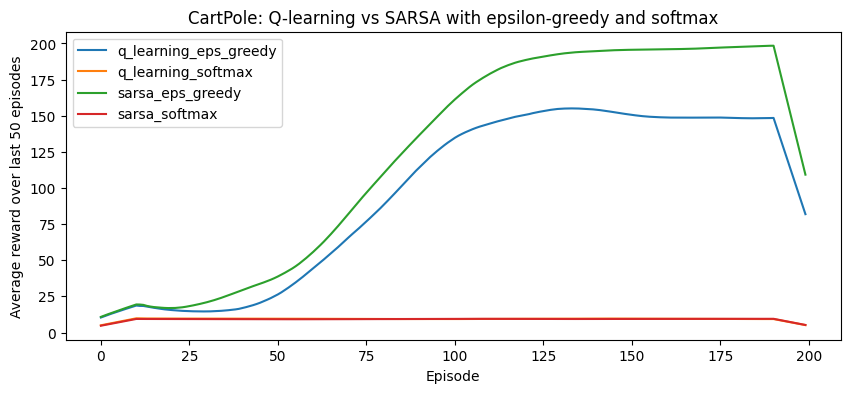

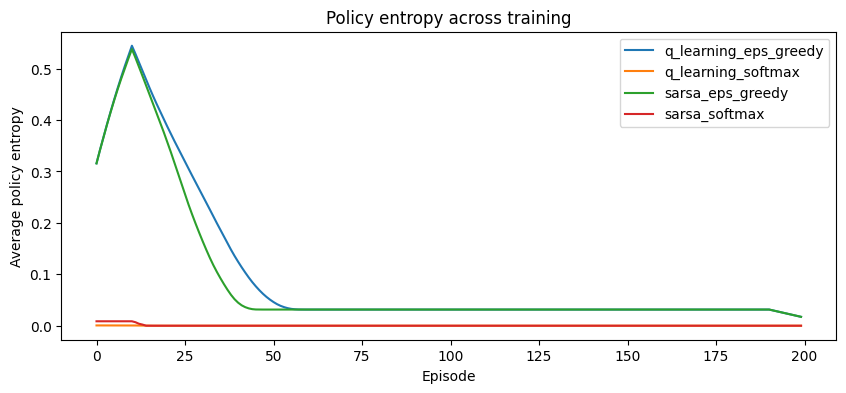

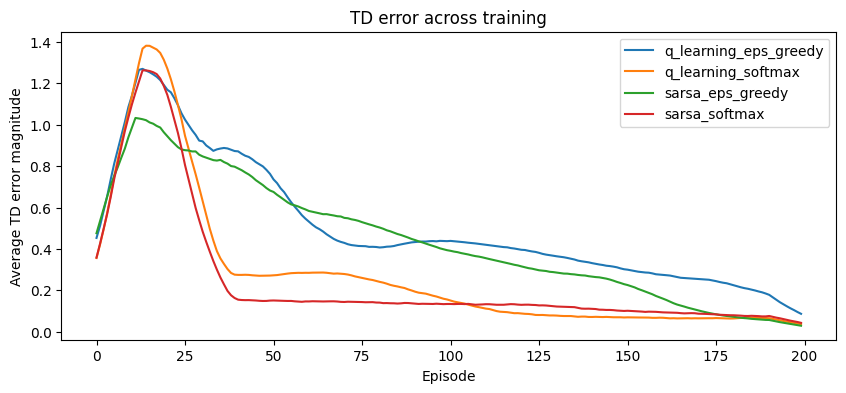

In [15]:
EPISODES = 200
BATCH_SIZE = 32
TEMPERATURE = 0.025


def moving_average(values, window=20):
    if len(values) < window:
        return np.array(values)
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="same")


def run_agent(algorithm, policy, temperature=TEMPERATURE, episodes=EPISODES, batch_size=BATCH_SIZE):
    env = gym.make('CartPole-v1')
    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n
    agent = DQNAgent(
        state_size,
        action_size,
        algorithm=algorithm,
        policy=policy,
        temperature=temperature,
    )

    reward_window = collections.deque(maxlen=50)
    rewards, avg_rewards = [], []
    greedy_fractions, policy_entropies, td_errors = [], [], []

    for e in range(episodes):
        state, _ = env.reset()
        state = np.reshape(state, [1, state_size])
        action, info = agent.act(state)

        total_reward = 0.0
        greedy_count = 0
        entropy_sum = 0.0
        td_error_values = []
        steps = 0

        for _ in range(200):
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = np.reshape(next_state, [1, state_size])

            if done:
                next_action = None
                next_info = {"is_greedy": 0, "entropy": 0.0}
            else:
                next_action, next_info = agent.act(next_state)

            agent.remember(state, action, reward, next_state, next_action, done)
            if len(agent.memory) > batch_size:
                td_error = agent.replay(batch_size)
                if td_error is not None:
                    td_error_values.append(td_error)

            total_reward += reward
            greedy_count += info["is_greedy"]
            entropy_sum += info["entropy"]
            steps += 1

            state = next_state
            action = next_action
            info = next_info

            if done:
                break

        reward_window.append(total_reward)
        rewards.append(total_reward)
        avg_rewards.append(np.mean(reward_window))
        greedy_fractions.append(greedy_count / max(steps, 1))
        policy_entropies.append(entropy_sum / max(steps, 1))
        td_errors.append(np.mean(td_error_values) if td_error_values else 0.0)

        print(
            f"[{algorithm} | {policy}] episode: {e+1}/{episodes}, "
            f"score: {total_reward:.1f}, epsilon: {agent.epsilon:.3f}, "
            f"last 50 avg reward: {avg_rewards[-1]:.2f}"
        )

    env.close()
    return {
        "rewards": rewards,
        "avg_rewards": avg_rewards,
        "greedy_fraction": greedy_fractions,
        "policy_entropy": policy_entropies,
        "td_error": td_errors,
    }


results = {
    "q_learning_eps_greedy": run_agent("q_learning", "epsilon_greedy"),
    "q_learning_softmax": run_agent("q_learning", "softmax"),
    "sarsa_eps_greedy": run_agent("sarsa", "epsilon_greedy"),
    "sarsa_softmax": run_agent("sarsa", "softmax"),
}

plt.figure(figsize=(10, 4))
for name, history in results.items():
    plt.plot(moving_average(history["avg_rewards"], 20), label=name)
plt.xlabel("Episode")
plt.ylabel("Average reward over last 50 episodes")
plt.title("CartPole: Q-learning vs SARSA with epsilon-greedy and softmax")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
for name, history in results.items():
    plt.plot(moving_average(history["policy_entropy"], 20), label=name)
plt.xlabel("Episode")
plt.ylabel("Average policy entropy")
plt.title("Policy entropy across training")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
for name, history in results.items():
    plt.plot(moving_average(history["td_error"], 20), label=name)
plt.xlabel("Episode")
plt.ylabel("Average TD error magnitude")
plt.title("TD error across training")
plt.legend()
plt.show()